In [1]:
using CellAdhesion
using DelimitedFiles
using Plots
using Statistics

find all the files in the data directory

In [2]:
data_dir_candidates = [
    joinpath(@__DIR__, "example_data"),
    joinpath(pkgdir(CellAdhesion), "docs", "src", "example_data"),
]
data_dir_idx = findfirst(isdir, data_dir_candidates)
data_dir_idx === nothing && error("Could not locate example_data directory")
data_dir = data_dir_candidates[data_dir_idx]
files = readdir(data_dir)

9-element Vector{String}:
 "stress_strain_Nonlinear_maxwell_1.0.txt"
 "stress_strain_Nonlinear_maxwell_10.0.txt"
 "stress_strain_Nonlinear_maxwell_100.0.txt"
 "stress_strain_Nonlinear_maxwell_20.0.txt"
 "stress_strain_Nonlinear_maxwell_3.0.txt"
 "stress_strain_Nonlinear_maxwell_30.0.txt"
 "stress_strain_Nonlinear_maxwell_5.0.txt"
 "stress_strain_Nonlinear_maxwell_50.0.txt"
 "stress_strain_Nonlinear_maxwell_7.0.txt"

extract the strain rates from the file names

In [3]:
strain_rates = [parse(Float64, split(split(file, "_")[end], ".txt")[1]) for file in files]

9-element Vector{Float64}:
   1.0
  10.0
 100.0
  20.0
   3.0
  30.0
   5.0
  50.0
   7.0

reorder file names based on increasing strain rates

In [4]:
sorted_idx = sortperm(strain_rates)
files = files[sorted_idx]
strain_rates = strain_rates[sorted_idx]

9-element Vector{Float64}:
   1.0
   3.0
   5.0
   7.0
  10.0
  20.0
  30.0
  50.0
 100.0

Define the bond model (slip bond model)

In [5]:
model = SlipBondModel((k_on_0=3e-3,), (k_off_0=3e-4, f_1e=0.055))

BondModel{Slip}((k_on = 0.003f0, k_off_0 = 0.0003f0, f_1e = 0.055f0))

Define simulation parameters

In [6]:
N = 20               # Number of bonds in the junction
l = 1.0               # Distance between bonds

1.0

Run the Montecarlo simulations for the different files, 50 times each

In [7]:
n = 50                      # Number of simulations for each strain rate
n_f = length(strain_rates)  # Number of different strain rates to apply to the junction

9

run simulation for each strain rate and save the results in a dictionary

Junction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction brokenJunction b

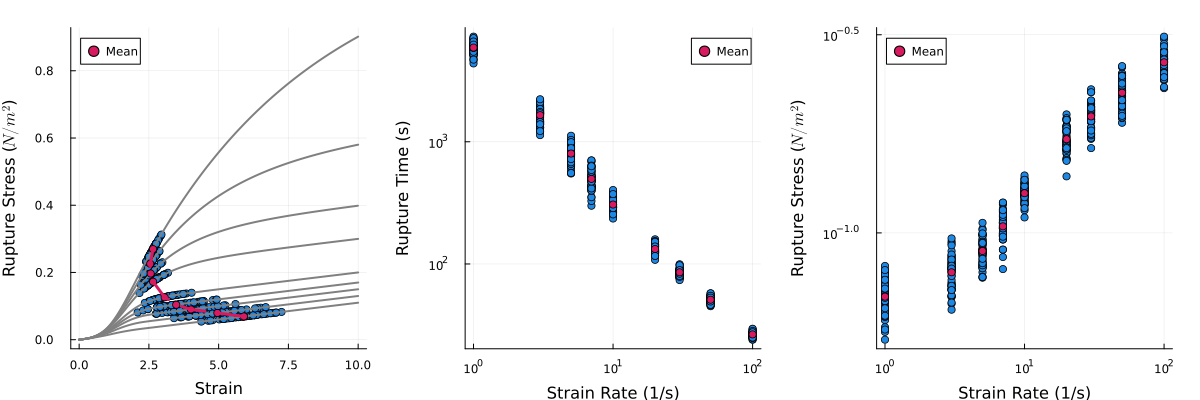

In [8]:
time_break = zeros(n_f)
stress_break = zeros(n_f)
strain_break = zeros(n_f)

p1 = plot()
p2 = plot()
p3 = plot()
for (i, strain_rate) in enumerate(strain_rates)
    # load the stress-time data from the file
    data = readdlm(joinpath(data_dir, files[i]))
    time = data[2:end, 1]   # ignore the header
    strain = data[2:end, 2]
    stress = data[2:end, 3]
    dt = time[2] - time[1]  # Calculate time step from the data
    max_steps = length(time)  # Set max_steps based on the length of the time data

    # convert stress to tension
    tension = stress .* N .* l  # Assuming stress is per bond, multiply by number of bonds and distance to get tension

    tension_break_v = zeros(n)
    time_break_v = zeros(n)
    strain_break_v = zeros(n)

    for repeat in 1:n
        # Define the junction
        x = Cluster(N, l, model, :force_global)

        # Run the simulation
        state, tension_break_v[repeat], time_break_v[repeat], step = runcluster(x, tension, dt; max_steps=max_steps, verbose=true)
    end
    tension_break_v /= N*l # Convert tension back to stress for plotting
    strain_break_v = [strain[argmin(abs.(time .- time_break_v[i]))] for i in 1:n]

    # Scatter plot of rupture times for the current strain rate
    scatter!(p1, strain_break_v, tension_break_v , label="", mc="#1E88E5", ms=4, ma=1)
    scatter!(p2, repeat([strain_rate], n), time_break_v, label="", mc="#1E88E5", ms=4, ma=1)
    scatter!(p3, repeat([strain_rate], n), tension_break_v , label="", mc="#1E88E5", ms=4, ma=1)

    # add the stress-strain curve for the current strain rate
    plot!(p1, strain, stress, label="", lw=2, color=:grey)

    # compute the means
    time_break[i] = mean(time_break_v)
    stress_break[i] = mean(tension_break_v)
    strain_break[i] = mean(strain_break_v)
end

scatter!(p1, strain_break, stress_break, label="Mean", mc="#D81B60", ms=4, ma=1)
scatter!(p2, strain_rates, time_break, label="Mean", mc="#D81B60", ms=4, ma=1)
scatter!(p3, strain_rates, stress_break, label="Mean", mc="#D81B60", ms=4, ma=1)
plot!(p1, xlabel="Strain", ylabel="Rupture Stress (\$N/m^2\$)")
plot!(p2, xlabel="Strain Rate (1/s)", ylabel="Rupture Time (s)", yscale=:log10, xscale=:log10)
plot!(p3, xlabel="Strain Rate (1/s)", ylabel="Rupture Stress (\$N/m^2\$)", yscale=:log10, xscale=:log10)

plot!(p1, strain_break, stress_break, label="", c="#D81B60", linewidth=3, linestyle=:dash)

plot(p1, p2, p3, layout=(1,3), size=(1200,400), margin=5Plots.mm)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*